In [2]:
from sklearn.datasets import load_iris
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Import TSNE
from sklearn.manifold import TSNE

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
iris = load_iris()
bc_data = load_breast_cancer()

X = pd.DataFrame(iris.data, columns=iris.feature_names)


# create temp_df to hold a 1-d array of 
temp_df = pd.Categorical.from_codes(iris.target, iris.target_names)

# take the temp_df and convert it to the full target df with a column for each iris type encoded 1 or 0
y = pd.get_dummies(temp_df,prefix=None, prefix_sep=None,dtype=int )

# y_int is created as a simple integer labelled variable (in an array)
y_int = pd.DataFrame(iris.target, columns=["species_int_label"]).values.reshape(-1)



In [3]:
#print (y_int)
print(iris.feature_names)
print(iris.target_names)


['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


In [4]:
# View the features and target variable
print(X.head())
print (len(X))
print(y.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
150
   setosa  versicolor  virginica
0       1           0          0
1       1           0          0
2       1           0          0
3       1           0          0
4       1           0          0


In [5]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,
random_state=20260310, stratify=y)


#instantiate the model
knn = KNeighborsClassifier(n_neighbors=6)
#fit the model to the training dataset
knn.fit(X_train, y_train)
# this code performance scores the model against the test data and prints the result as “accuracy”
print(knn.score(X_test, y_test))

# predict the target values as y_pred
y_pred = knn.predict(X_test)

# print the classification report comparing actual target against predicted target
print(classification_report(y_test, y_pred) ) # prints 



0.868421052631579
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.91      0.77      0.83        13
           2       0.77      0.83      0.80        12

   micro avg       0.89      0.87      0.88        38
   macro avg       0.89      0.87      0.88        38
weighted avg       0.90      0.87      0.88        38
 samples avg       0.87      0.87      0.87        38



c:\Users\tombe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


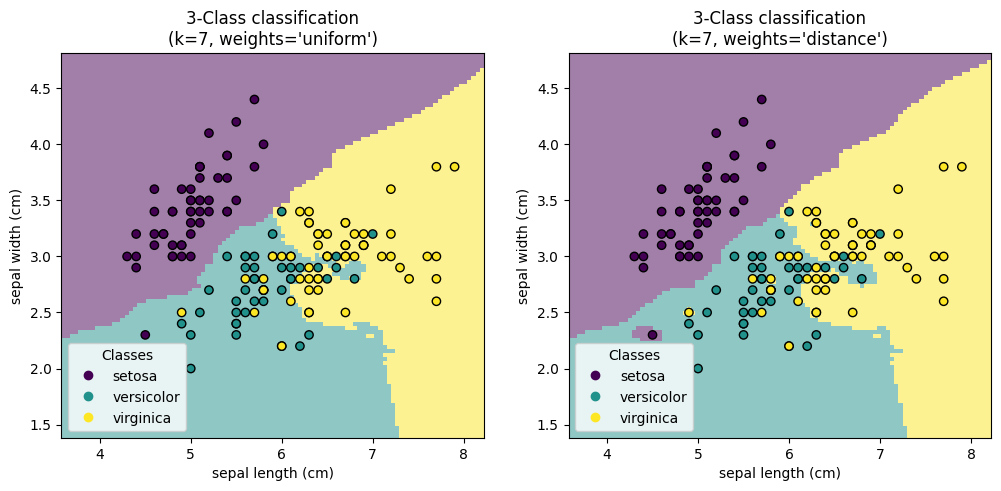

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris(as_frame=True)
X_2 = iris.data[["sepal length (cm)", "sepal width (cm)"]]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X_2, y, stratify=y, random_state=0)


from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=7))]
)

import matplotlib.pyplot as plt

from sklearn.inspection import DecisionBoundaryDisplay

_, axs = plt.subplots(ncols=2, figsize=(12, 5))

for ax, weights in zip(axs, ("uniform", "distance")):
    clf.set_params(knn__weights=weights).fit(X_train, y_train)
    disp = DecisionBoundaryDisplay.from_estimator(
        clf,
        X_test,
        response_method="predict",
        plot_method="pcolormesh",
        xlabel=iris.feature_names[0],
        ylabel=iris.feature_names[1],
        shading="auto",
        alpha=0.5,
        ax=ax,
    )
    scatter = disp.ax_.scatter(X.iloc[:, 0], X.iloc[:, 1], c=y, edgecolors="k")
    disp.ax_.legend(
        scatter.legend_elements()[0],
        iris.target_names,
        loc="lower left",
        title="Classes",
    )
    _ = disp.ax_.set_title(
        f"3-Class classification\n(k={clf[-1].n_neighbors}, weights={weights!r})"
    )

plt.show()

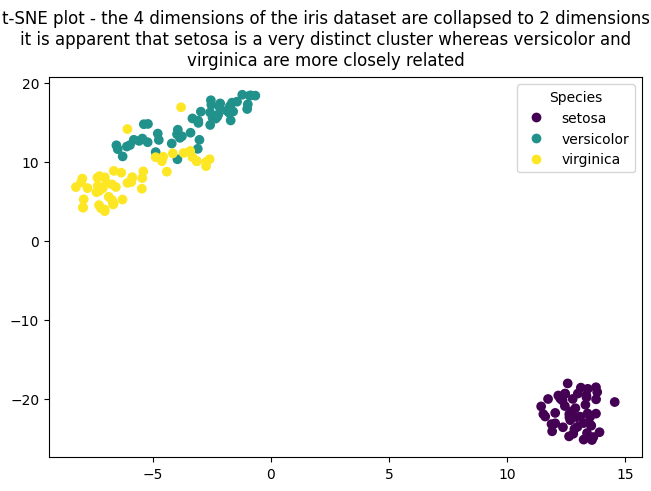

In [7]:
# Create a TSNE instance: model
model = TSNE(learning_rate=200)

# Apply fit_transform to samples: tsne_features
tsne_features = model.fit_transform(X)

xs = tsne_features[:,0]  # Select the 0th feature: xs
ys = tsne_features[:,1]  # Select the 1st feature: ys

# Scatter plot, coloring by species
fig, ax = plt.subplots(layout="constrained")
scatter = ax.scatter(xs, ys, c=y_int)

# Add this line to extract handles for the legend
handles, _ = scatter.legend_elements()

# use slightly abstract method to create the legend
legend1 = ax.legend(
    handles,
    iris.target_names.tolist(),
    loc="upper right",
    title="Species"
)

# create an st object (the suptitle).  The st object allows a text method to be applied - that is: the set_wrap method to autmatically wrap the rather long tile!
st = plt.suptitle("t-SNE plot - the 4 dimensions of the iris dataset are collapsed to 2 dimensions it is apparent that setosa is a very distinct cluster whereas versicolor and virginica are more closely related")
st.set_wrap(True)

plt.show()

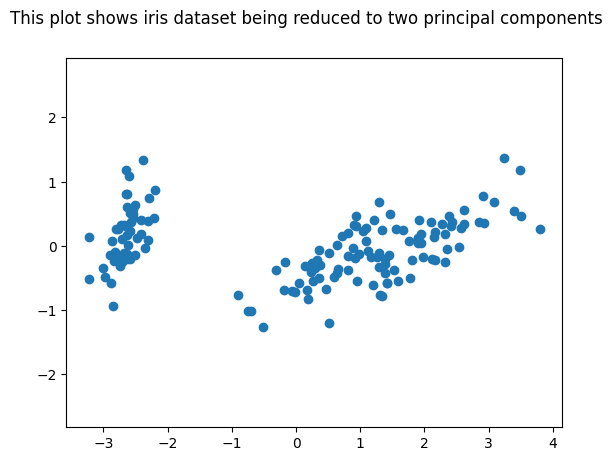

2.120222400425753e-14


In [8]:

# THIS CELL GIVES AN EXAMPLE OF APPLYING PCA TO THE IRIS DATASET

from sklearn.decomposition import PCA
from scipy.stats import pearsonr

# instantiate and fit the PCA model
model = PCA()
#pca_iris = PCA(n_components=2)
model.fit(X)

# EXTRACT MEAN OF DATA AND FIRST PCA VECTOR TO OVERLAY ON TOP OF ORIGINAL DATA 
#mean = model.mean_ # Get the mean of the grain samples: mean
#first_pc = model.components_[0,:] # Get the first principal component: first_pc

#ax1.arrow(mean[0], mean[1], first_pc[0], first_pc[1], color='red', width=0.01)  # Plot first_pc as an arrow, starting at mean
#ax1.axis('equal')  # Keep axes on same scale 
#title1 = ax1.set_title("Scatter plot of original data, together with an arrow shwoing the principal PCA vector starting at the centroid of the data points")
#title1.set_wrap(True)

# TRANSFORM THE ORIGINAL DATA AND PLOT THE TRANSFORMED COORDINATES
pca_features = model.transform(X) # Apply the fit_transform method of model to X: pca_features
xs = pca_features[:,0]      # Assign 0th column of pca_features: xs
ys = pca_features[:,1]      # Assign 1st column of pca_features: ys


# print (transformed)
# Scatter plot xs vs ys
#plt.scatter(xs, ys, c=y_int)
plt.scatter(xs, ys)
plt.axis('equal')
plt.suptitle("This plot shows iris dataset being reduced to two principal components")

plt.show()

correlation, pvalue = pearsonr(xs, ys) # Calculate the Pearson correlation of xs and ys
print(correlation) # Display the correlation


range(0, 4)


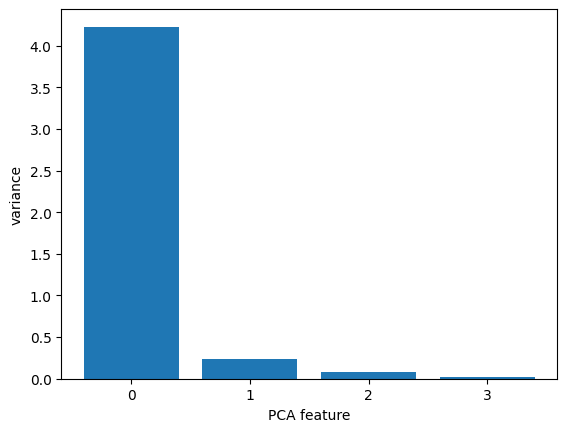

In [9]:

features = range(model.n_components_)
print(features)
plt.bar(features, model.explained_variance_)
plt.xticks(features)
plt. ylabel ('variance')
plt.xlabel ('PCA feature')
plt.show()